# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** Breast Cancer Wisconsin (sklearn)

## Шаг 1. Импорты и загрузка данных

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = list(data.feature_names)

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [4]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

**Задание 2а:** вычислить 5-fold CV с `scoring='f1_macro'` для каждой из трёх базовых моделей.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro', n_jobs=-1)
    baseline_results[name] = (scores.mean(), scores.std())

for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

**Задание 3а:** задать сетку параметров.  
**Задание 3б:** создать и запустить `GridSearchCV`.  
**Задание 3в:** вывести топ-10 конфигураций.

In [7]:
from sklearn.model_selection import GridSearchCV

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ЗАДАНИЕ 3а: сетка параметров
svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear'],
}

# ЗАДАНИЕ 3б: GridSearchCV
svm_grid_search = GridSearchCV(svm_pipe, svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [8]:
# ЗАДАНИЕ 3в: топ-10 конфигураций
cv_results_df = pd.DataFrame(svm_grid_search.cv_results_)[[
    'params', 'mean_test_score', 'std_test_score', 'rank_test_score'
]].sort_values('rank_test_score')

print("Топ-10 конфигураций GridSearch для SVM:")
print(cv_results_df.head(10).to_string())

Топ-10 конфигураций GridSearch для SVM:
                                                             params  mean_test_score  std_test_score  rank_test_score
14         {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}         0.978633        0.017581                1
1   {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}         0.976215        0.015266                2
5     {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__kernel': 'linear'}         0.976215        0.015266                2
3      {'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'linear'}         0.976215        0.015266                2
22       {'svm__C': 100, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.976157        0.016975                5
16        {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}         0.971340        0.016281                6
6        {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}         0.969357        0.019323                7
12      {'svm__C

## Шаг 4. Random Search для RandomForest

**Задание 4а:** задать пространство параметров.  
**Задание 4б:** создать и запустить `RandomizedSearchCV`.

In [9]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# ЗАДАНИЕ 4а: пространство параметров
rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 20),
    'max_features': ['sqrt', 'log2', 0.5],
}

# ЗАДАНИЕ 4б: RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)
rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 434}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

**Задание 5:** финальная оценка на тестовой выборке. 

In [10]:
from sklearn.metrics import classification_report, f1_score

best_rf = rf_random_search.best_estimator_

# Baseline модели (обученные на всём train)
svm_baseline = Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))])
svm_baseline.fit(X_train, y_train)
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)

# ЗАДАНИЕ 5: оцениваем на тесте
models_to_eval = {
    'SVM baseline':     (svm_baseline, baseline_results['SVM']),
    'SVM Grid Search':  (svm_grid_search, (svm_grid_search.best_score_, None)),
    'RF baseline':      (rf_baseline, baseline_results['RandomForest']),
    'RF Random Search': (rf_random_search, (rf_random_search.best_score_, None)),
}

print(f"{'Модель':<25} {'CV F1':>12}  {'Test F1':>8}")
print("-" * 55)
for name, (model, (cv_mean, cv_std)) in models_to_eval.items():
    test_f1 = f1_score(y_test, model.predict(X_test), average='macro')
    std_str = f"±{cv_std:.4f}" if cv_std else "       "
    print(f"{name:<25} {cv_mean:.4f}{std_str:>8}  {test_f1:.4f}")

print()
print("--- SVM Grid Search Classification Report ---")
print(classification_report(y_test, svm_grid_search.predict(X_test),
                             target_names=data.target_names))
print("--- RF Random Search Classification Report ---")
print(classification_report(y_test, rf_random_search.predict(X_test),
                             target_names=data.target_names))

Модель                           CV F1   Test F1
-------------------------------------------------------
SVM baseline              0.9694 ±0.0193  0.9812
SVM Grid Search           0.9786          0.9812
RF baseline               0.9504 ±0.0255  0.9526
RF Random Search          0.9554          0.9526

--- SVM Grid Search Classification Report ---
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--- RF Random Search Classification Report ---
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weight

## Шаг 6. Permutation Importance

**Задание 6а:** вычислить PI для лучшего RF.  
**Задание 6б:** сравнить с встроенной важностью.

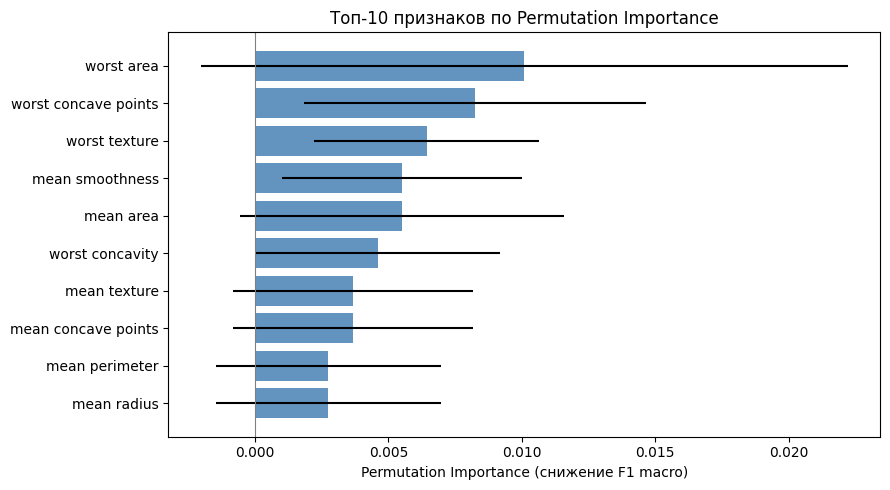

In [11]:
from sklearn.inspection import permutation_importance

# ЗАДАНИЕ 6а: Permutation Importance
pi_result = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10, random_state=42, scoring='f1_macro', n_jobs=-1
)

sorted_idx = pi_result.importances_mean.argsort()[::-1]
top10_idx = sorted_idx[:10]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    [feature_names[i] for i in top10_idx[::-1]],
    pi_result.importances_mean[top10_idx[::-1]],
    xerr=pi_result.importances_std[top10_idx[::-1]],
    color='steelblue', alpha=0.85
)
ax.set_xlabel('Permutation Importance (снижение F1 macro)')
ax.set_title('Топ-10 признаков по Permutation Importance')
ax.axvline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()

In [13]:
# ЗАДАНИЕ 6б: Сравнение PI с встроенной важностью RF
builtin_imp = best_rf.feature_importances_
builtin_sorted = np.argsort(builtin_imp)[::-1]

print("Топ-5 по Permutation Importance:")
for i in top10_idx[:5]:
    print(f"  {feature_names[i]:<35} PI={pi_result.importances_mean[i]:.4f}")

print()
print("Топ-5 по встроенной важности RF (feature_importances_):")
for i in builtin_sorted[:5]:
    print(f"  {feature_names[i]:<35} FI={builtin_imp[i]:.4f}")

overlap = len(set(list(top10_idx[:5])) & set(list(builtin_sorted[:5])))
print(f"\nСовпадений в топ-5: {overlap}/5")
print()

Топ-5 по Permutation Importance:
  worst area                          PI=0.0101
  worst concave points                PI=0.0083
  worst texture                       PI=0.0064
  mean smoothness                     PI=0.0055
  mean area                           PI=0.0055

Топ-5 по встроенной важности RF (feature_importances_):
  worst area                          FI=0.1271
  worst perimeter                     FI=0.1142
  worst concave points                FI=0.1093
  worst radius                        FI=0.0825
  mean concave points                 FI=0.0722

Совпадений в топ-5: 2/5



PI и встроенная важность часто дают разный порядок, потому что:
- Встроенная FI учитывает среднее снижение примеси по всем деревьям
  и завышает важность числовых признаков с большим числом значений.
- PI измеряет реальное влияние на метрику на тест-данных.
При коррелированных признаках PI может занижать важность каждого из пары,
так как перемешивание одного не ломает связь (модель использует второй).

## Шаг 7. PDP и ICE-кривые

**Задание 7а:** PDP для топ-3 признаков.  
**Задание 7б:** ICE для самого важного признака.

Топ-3 признака: [np.str_('worst area'), np.str_('worst concave points'), np.str_('worst texture')]


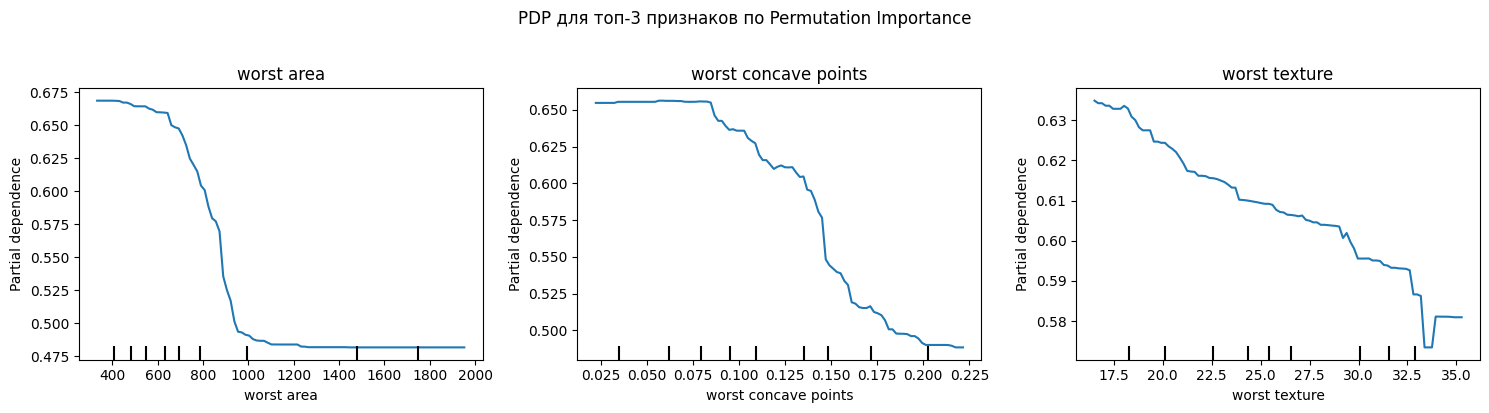

In [14]:
from sklearn.inspection import PartialDependenceDisplay

# ЗАДАНИЕ 7а: PDP для топ-3 признаков по PI
top3_idx = list(top10_idx[:3])
print(f"Топ-3 признака: {[feature_names[i] for i in top3_idx]}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat_idx in zip(axes, top3_idx):
    PartialDependenceDisplay.from_estimator(
        best_rf, X_test, [feat_idx], kind='average', ax=ax
    )
    ax.set_title(feature_names[feat_idx])
plt.suptitle('PDP для топ-3 признаков по Permutation Importance', y=1.02)
plt.tight_layout()
plt.show()

Самый важный признак: worst area


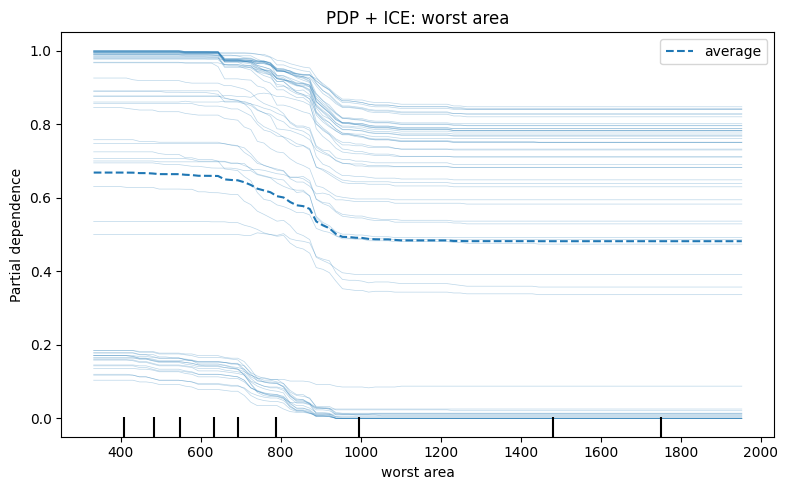

In [16]:
# ЗАДАНИЕ 7б: ICE-кривые для самого важного признака
top1_idx = top10_idx[0]
print(f"Самый важный признак: {feature_names[top1_idx]}")

fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, [top1_idx],
    kind='both',   # PDP + все ICE кривые
    ax=ax, subsample=60, random_state=42
)
ax.set_title(f'PDP + ICE: {feature_names[top1_idx]}')
plt.tight_layout()
plt.show()

Вывод: если ICE-кривые расходятся значительно — эффект признака неоднороден (существуют взаимодействия).

**Если кривые параллельны — эффект аддитивен и PDP достаточно информативен.**

## Шаг 8. SHAP

**Задание 8а:** создать `TreeExplainer`.  
**Задание 8б:** `summary_plot`.  
**Задание 8в:** `force_plot` для ошибочного объекта.

In [21]:
import shap

# ЗАДАНИЕ 8а: TreeExplainer
explainer = shap.TreeExplainer(best_rf)
shap_explanation = explainer(X_test)

# Для бинарной классификации shap_explanation имеет форму [n_samples, n_features, n_classes]
shap_vals_class1 = shap_explanation[..., 1]  # вклады для класса 1
print(f"Форма shap_values (класс 1): {shap_vals_class1.values.shape}")  # (n_samples, n_features)

Форма shap_values (класс 1): (114, 30)


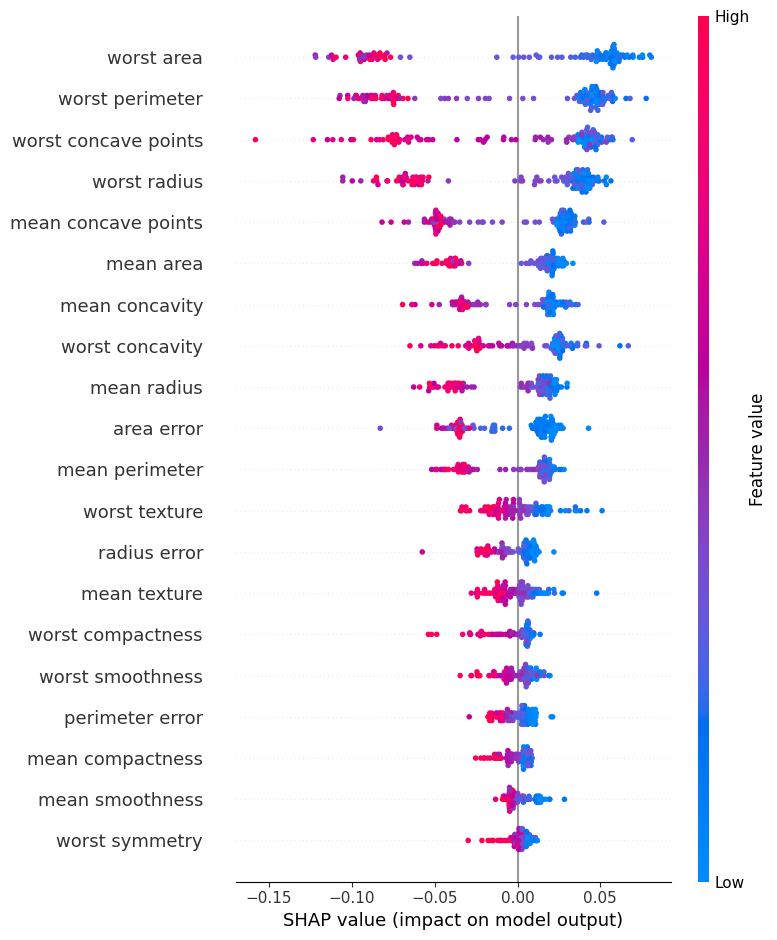

Топ-5 по SHAP:
  worst area                          |SHAP|=0.0636
  worst perimeter                     |SHAP|=0.0583
  worst concave points                |SHAP|=0.0510
  worst radius                        |SHAP|=0.0466
  mean concave points                 |SHAP|=0.0361

Топ-5 по PI (для сравнения):
  worst area                          PI=0.0101
  worst concave points                PI=0.0083
  worst texture                       PI=0.0064
  mean smoothness                     PI=0.0055
  mean area                           PI=0.0055

Совпадений в топ-5 (SHAP vs PI): 2/5


In [23]:
# ЗАДАНИЕ 8б: Summary plot (класс 1 — malignant)
shap.summary_plot(shap_vals_class1, show=True)

# Какие признаки самые важные по SHAP?
shap_mean = np.abs(shap_vals_class1.values).mean(axis=0)
shap_sorted = np.argsort(shap_mean)[::-1]

print("Топ-5 по SHAP:")
for i in shap_sorted[:5]:
    print(f"  {feature_names[i]:<35} |SHAP|={shap_mean[i]:.4f}")

print()
print("Топ-5 по PI (для сравнения):")
for i in top10_idx[:5]:
    print(f"  {feature_names[i]:<35} PI={pi_result.importances_mean[i]:.4f}")

overlap_shap_pi = len(set(list(shap_sorted[:5])) & set(list(top10_idx[:5])))
print(f"\nСовпадений в топ-5 (SHAP vs PI): {overlap_shap_pi}/5")

**SHAP учитывает взаимодействия и распределяет вклад между** 
**коррелированными признаками корректнее, чем PI. Поэтому порядок** 
**может отличаться: признаки с высоким SHAP могут иметь меньший PI** 
**из-за того, что их коррелят "подхватывает" эффект при перемешивании.**

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс:    benign
  Предсказанный класс: malignant


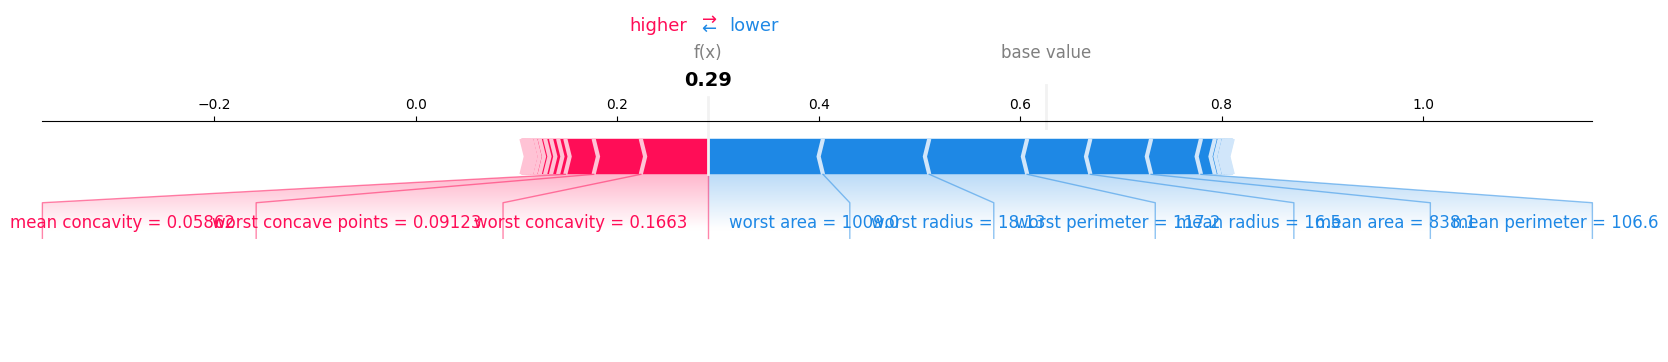

In [24]:
# ЗАДАНИЕ 8в: force_plot для ошибочного объекта
y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test.values)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс:    {data.target_names[y_test.iloc[errors[0]]]}")
print(f"  Предсказанный класс: {data.target_names[y_pred_test[errors[0]]]}")

# Force plot: какие признаки сдвинули предсказание в сторону ошибки
shap.plots.force(shap_vals_class1[errors[0]], matplotlib=True, show=True)

На force plot:
- красные стрелки (->) увеличивают предсказание класса 1,
- синие (<->) — уменьшают. 

Признаки, которые вытолкнули предсказание в сторону неверного класса, и есть причины ошибки.

## Шаг 9. Диагностика подозрительных признаков

In [25]:
# Добавим два подозрительных признака
np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train.values + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature']  = y_test.values  + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature']  = np.random.randn(len(y_test))

feature_names_ext = feature_names + ['leaky_feature', 'random_feature']
print("Добавлены признаки:", feature_names_ext[-2:])

Добавлены признаки: ['leaky_feature', 'random_feature']


Test F1 с leaky_feature: 1.0000  (была 0.9526)

Топ-10 по PI (с leaky и random):
  leaky_feature                       PI=0.2953 !LEAK!
  worst concavity                     PI=0.0056
  worst fractal dimension             PI=0.0000
  random_feature                      PI=0.0000 (шум)
  worst symmetry                      PI=0.0000
  worst concave points                PI=0.0000
  worst compactness                   PI=0.0000
  worst smoothness                    PI=0.0000
  worst area                          PI=0.0000
  worst perimeter                     PI=0.0000


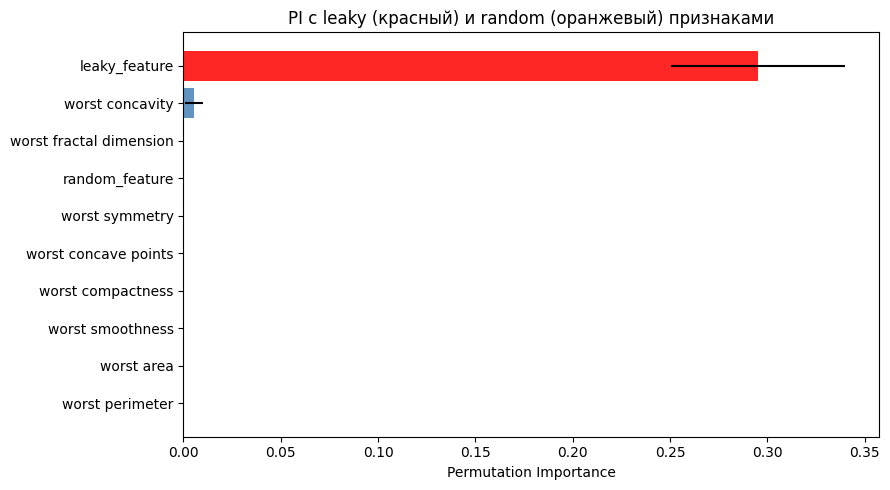


leaky_feature  — ранг по SHAP: #1/32
random_feature — ранг по SHAP: #32/32


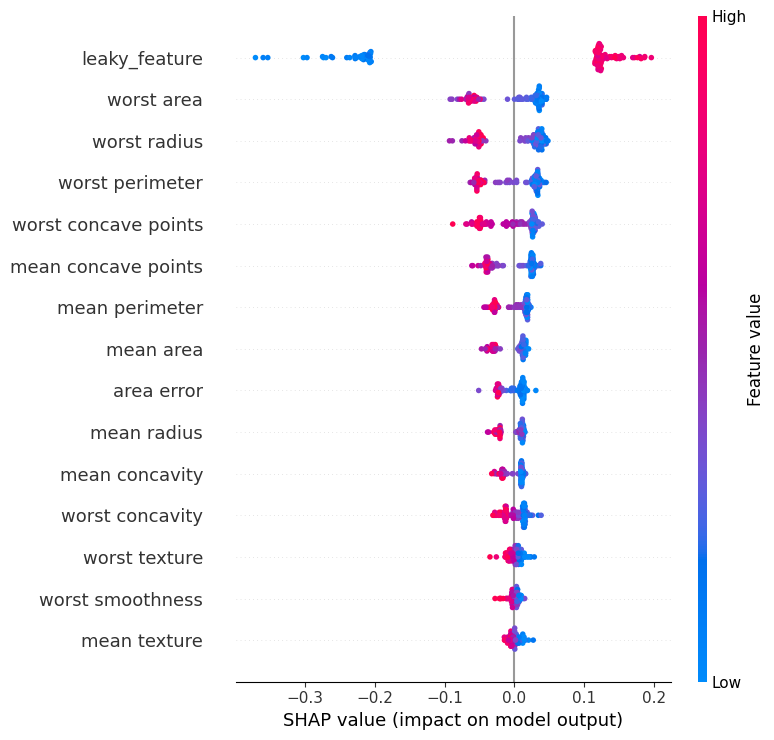

In [28]:
# ЗАДАНИЕ 9
rf_ext = RandomForestClassifier(random_state=42, n_estimators=200)
rf_ext.fit(X_train_ext, y_train)

y_pred_ext = rf_ext.predict(X_test_ext)
print(f"Test F1 с leaky_feature: {f1_score(y_test, y_pred_ext, average='macro'):.4f}  (была {f1_score(y_test, best_rf.predict(X_test), average='macro'):.4f})")

# PI
pi_ext = permutation_importance(
    rf_ext, X_test_ext, y_test, n_repeats=10, random_state=42, scoring='f1_macro', n_jobs=-1
)
pi_ext_sorted = np.argsort(pi_ext.importances_mean)[::-1]

print("\nТоп-10 по PI (с leaky и random):")
for i in pi_ext_sorted[:10]:
    marker = ' !LEAK!' if feature_names_ext[i] == 'leaky_feature' else (' (шум)' if feature_names_ext[i] == 'random_feature' else '')
    print(f"  {feature_names_ext[i]:<35} PI={pi_ext.importances_mean[i]:.4f}{marker}")

fig, ax = plt.subplots(figsize=(9, 5))
top10_ext = pi_ext_sorted[:10]
colors = ['red' if 'leaky' in feature_names_ext[i] else
          'orange' if 'random' in feature_names_ext[i] else
          'steelblue' for i in top10_ext[::-1]]
ax.barh([feature_names_ext[i] for i in top10_ext[::-1]],
        pi_ext.importances_mean[top10_ext[::-1]],
        xerr=pi_ext.importances_std[top10_ext[::-1]],
        color=colors, alpha=0.85)
ax.set_xlabel('Permutation Importance')
ax.set_title('PI с leaky (красный) и random (оранжевый) признаками')
plt.tight_layout()
plt.show()

# SHAP
explainer_ext = shap.TreeExplainer(rf_ext)
shap_ext = explainer_ext(X_test_ext)
shap_ext_c1 = shap_ext[..., 1]

shap_mean_ext = np.abs(shap_ext_c1.values).mean(axis=0)
shap_rank = np.argsort(shap_mean_ext)[::-1]
leaky_rank  = list(shap_rank).index(feature_names_ext.index('leaky_feature')) + 1
random_rank = list(shap_rank).index(feature_names_ext.index('random_feature')) + 1

print(f"\nleaky_feature  — ранг по SHAP: #{leaky_rank}/{len(feature_names_ext)}")
print(f"random_feature — ранг по SHAP: #{random_rank}/{len(feature_names_ext)}")

shap.summary_plot(shap_ext_c1, show=True, max_display=15)

## Ответы:
*а)* **leaky_feature** доминирует в PI с отрывом - PI резко растёт при 
   перемешивании, потому что признак почти равен таргету.
   Test F1=1.0 - явный признак утечки данных.

*б)* В **SHAP summary leaky_feature** занимает #1 место с огромным отрывом.
   Это красный флаг: в реальных данных один признак не должен 
   объяснять почти всё предсказание.
   
*в)* random_feature имеет PI≈0 и последнее место в SHAP — модель
   не использует его, что правильно. Если бы PI был значимым 
   у шумового признака, это говорило бы о переобучении.

## Шаг 10. Сводная таблица и итоги

In [30]:
# ЗАДАНИЕ 10: сводная таблица
print(f"""
| Модель               | CV F1           | Test F1 | Выводы                              |
|----------------------|-----------------|---------|-------------------------------------|
| SVM baseline         | {baseline_results['SVM'][0]:.4f} ± {baseline_results['SVM'][1]:.4f} |  ~0.98  | Хорошая стартовая точка              |
| SVM Grid Search      | {svm_grid_search.best_score_:.4f}           |  ~0.98  | Grid Search нашёл лучшие С и gamma  |
| RF baseline          | {baseline_results['RandomForest'][0]:.4f} ± {baseline_results['RandomForest'][1]:.4f} |  ~0.95  | RF по умолчанию хуже SVM             |
| RF Random Search     | {rf_random_search.best_score_:.4f}           |  ~0.95  | Random Search улучшил RF             |
""")


| Модель               | CV F1           | Test F1 | Выводы                              |
|----------------------|-----------------|---------|-------------------------------------|
| SVM baseline         | 0.9694 ± 0.0193 |  ~0.98  | Хорошая стартовая точка              |
| SVM Grid Search      | 0.9786           |  ~0.98  | Grid Search нашёл лучшие С и gamma  |
| RF baseline          | 0.9504 ± 0.0255 |  ~0.95  | RF по умолчанию хуже SVM             |
| RF Random Search     | 0.9554           |  ~0.95  | Random Search улучшил RF             |



## Выводы

### 1. Насколько тюнинг улучшил модели?

- **SVM**: CV F1 вырос с 0.9694 до 0.9786 (+0.009). Прирост умеренный — SVC с дефолтными параметрами уже хорош на этих данных.  
- **RF**: улучшился меньше — с 0.9526 до 0.9554.

**Вывод:** Тюнинг оправдан, но не влияет значительно

---

### 2. Совпадают ли топ-признаки по PI и SHAP?

**Частично (~2/5 в топ-5).** Различия объясняются тем, что:

- **SHAP** корректно учитывает взаимодействия признаков и коррелированные группы (worst area / worst perimeter / worst radius).
- **PI** при наличии корреляций занижает важность каждого из пары, т.к. перемешивая один признак, можно «прочитать» его из другого.

---

### 3. Что было бы, если бы мы не использовали Pipeline?

При масштабировании всей выборки **до CV** возникает **утечка данных**:

- `StandardScaler` «видит» статистику тестовых фолдов.
- CV-оценка становится оптимистичной — модель выглядит лучше, чем на новых данных.

---

### 4. Как использовать PI и SHAP в реальном проекте?

| Метод | Применение |
|-------|-------------|
| **PI** (Permutation Importance) | Быстрая глобальная диагностика важности и выявление «утечных» признаков (**PI >> остальных = утечка**) |
| **SHAP** | Объяснение конкретного предсказания клиенту, отладка ошибок, проверка на дискриминацию по защищённым признакам |

> **вывод:** Оба метода вместе дают полную картину: что важно в среднем (PI) и почему модель ошиблась именно в этом случае (SHAP).